100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]



Training Simple CNN...
Epoch 1/5 - Train Loss: 1.3047, Val Loss: 0.5969
Epoch 2/5 - Train Loss: 0.8781, Val Loss: 0.5439
Epoch 3/5 - Train Loss: 0.7879, Val Loss: 0.5432
Epoch 4/5 - Train Loss: 0.7251, Val Loss: 0.4863
Epoch 5/5 - Train Loss: 0.6778, Val Loss: 0.4208

Training ResNet18...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Epoch 1/5 - Train Loss: 0.3141, Val Loss: 0.2430
Epoch 2/5 - Train Loss: 0.2137, Val Loss: 0.2705
Epoch 3/5 - Train Loss: 0.1755, Val Loss: 0.2291
Epoch 4/5 - Train Loss: 0.1478, Val Loss: 0.2007
Epoch 5/5 - Train Loss: 0.1227, Val Loss: 0.2089

Accuracy Comparison:
Simple CNN Accuracy: 0.8652
ResNet18 Accuracy: 0.9313


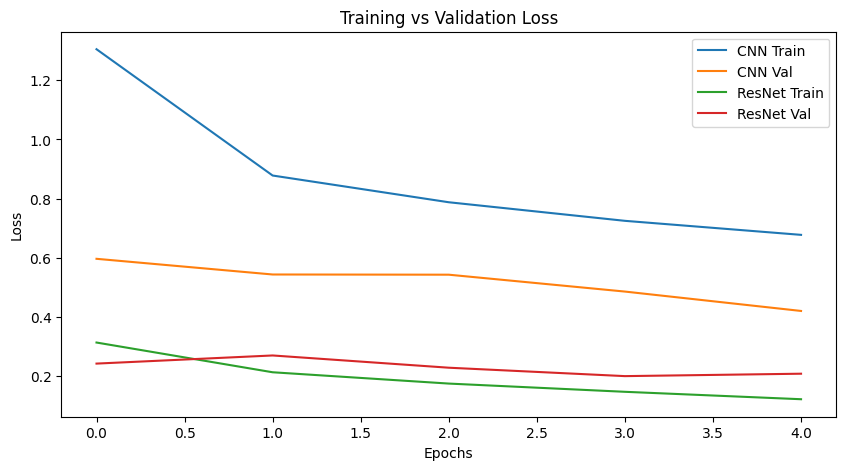

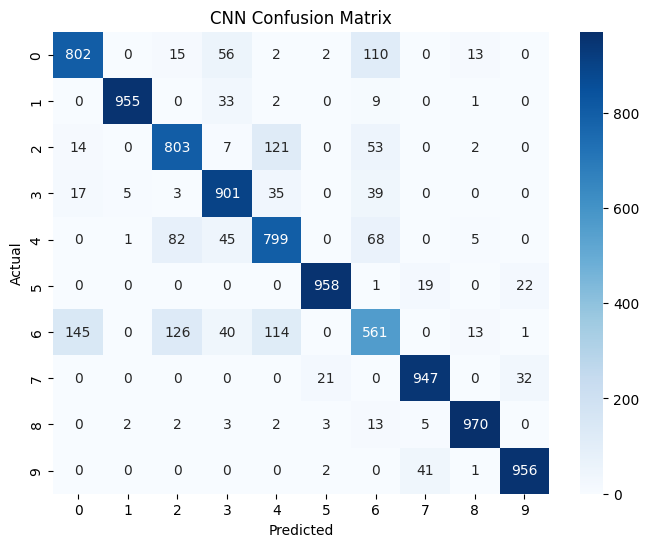

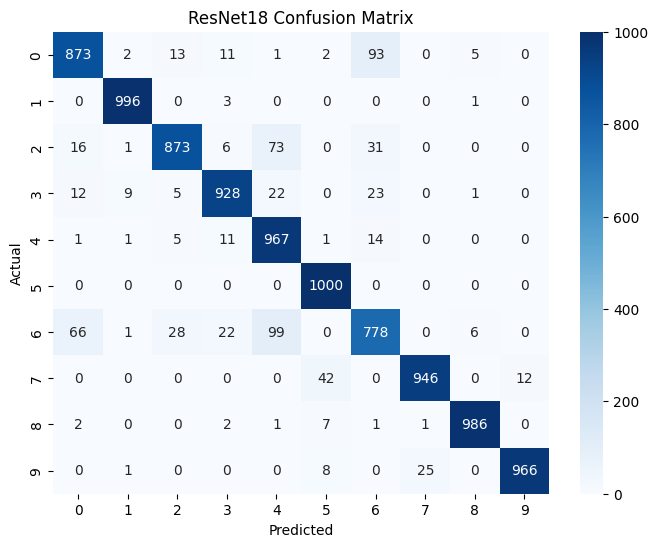


Model Comparison:
Simple CNN Params: 25.71 Million
ResNet18 Params: 11.18 Million
Simple CNN Training Time: 791.56 sec
ResNet18 Training Time: 1137.48 sec


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = train_dataset.classes

# -----------------------------
# Model 1: Simple CNN
# -----------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# -----------------------------
# Model 2: Transfer Learning (ResNet18)
# -----------------------------
def get_resnet():
    model = models.resnet18(pretrained=True)

    # Change input layer (1 channel instead of 3)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Replace final layer
    model.fc = nn.Linear(model.fc.in_features, 10)

    return model

# -----------------------------
# Training Function
# -----------------------------
def train_model(model, epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    total_time = time.time() - start_time
    return model, train_losses, val_losses, total_time

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(model):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.numpy())

    acc = accuracy_score(labels_list, preds)
    cm = confusion_matrix(labels_list, preds)

    return acc, cm

# -----------------------------
# Train Models
# -----------------------------
print("\nTraining Simple CNN...")
cnn = SimpleCNN()
cnn, cnn_train_loss, cnn_val_loss, cnn_time = train_model(cnn)

print("\nTraining ResNet18...")
resnet = get_resnet()
resnet, res_train_loss, res_val_loss, res_time = train_model(resnet)

# -----------------------------
# Evaluate
# -----------------------------
cnn_acc, cnn_cm = evaluate(cnn)
res_acc, res_cm = evaluate(resnet)

print("\nAccuracy Comparison:")
print(f"Simple CNN Accuracy: {cnn_acc:.4f}")
print(f"ResNet18 Accuracy: {res_acc:.4f}")

# -----------------------------
# Plot Loss Curves
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(cnn_train_loss, label='CNN Train')
plt.plot(cnn_val_loss, label='CNN Val')

plt.plot(res_train_loss, label='ResNet Train')
plt.plot(res_val_loss, label='ResNet Val')

plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
def plot_cm(cm, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(cnn_cm, "CNN Confusion Matrix")
plot_cm(res_cm, "ResNet18 Confusion Matrix")

# -----------------------------
# Model Size Comparison
# -----------------------------
def model_size(model):
    return sum(p.numel() for p in model.parameters()) / 1e6  # in millions

print("\nModel Comparison:")
print(f"Simple CNN Params: {model_size(cnn):.2f} Million")
print(f"ResNet18 Params: {model_size(resnet):.2f} Million")

print(f"Simple CNN Training Time: {cnn_time:.2f} sec")
print(f"ResNet18 Training Time: {res_time:.2f} sec")

Using device: cuda

Training RNN model...
Epoch 10/50 - Train Loss: 0.0027, Val Loss: 0.0070
Epoch 20/50 - Train Loss: 0.0035, Val Loss: 0.0081
Epoch 30/50 - Train Loss: 0.0015, Val Loss: 0.0116
Epoch 40/50 - Train Loss: 0.0028, Val Loss: 0.0148
Epoch 50/50 - Train Loss: 0.0018, Val Loss: 0.0059
RNN RMSE: 0.0746

Training LSTM model...
Epoch 10/50 - Train Loss: 0.0066, Val Loss: 0.0158
Epoch 20/50 - Train Loss: 0.0041, Val Loss: 0.0114
Epoch 30/50 - Train Loss: 0.0027, Val Loss: 0.0076
Epoch 40/50 - Train Loss: 0.0025, Val Loss: 0.0097
Epoch 50/50 - Train Loss: 0.0021, Val Loss: 0.0088
LSTM RMSE: 0.0911

Training GRU model...
Epoch 10/50 - Train Loss: 0.0038, Val Loss: 0.0128
Epoch 20/50 - Train Loss: 0.0026, Val Loss: 0.0086
Epoch 30/50 - Train Loss: 0.0020, Val Loss: 0.0051
Epoch 40/50 - Train Loss: 0.0018, Val Loss: 0.0046
Epoch 50/50 - Train Loss: 0.0015, Val Loss: 0.0073
GRU RMSE: 0.0833


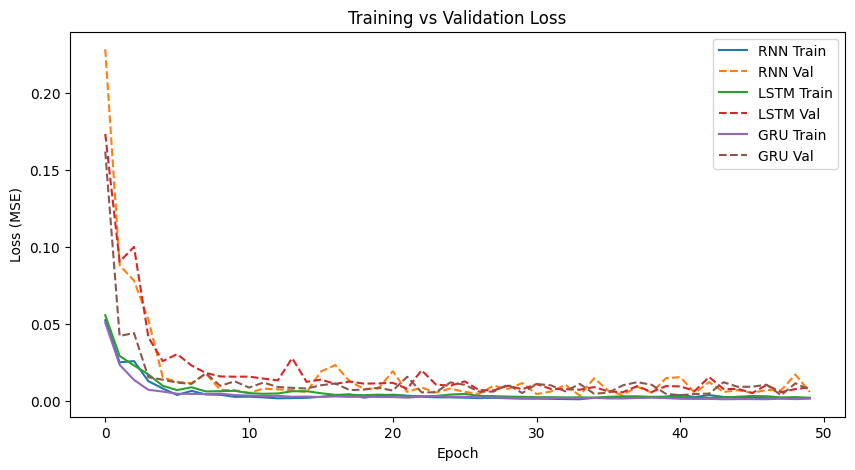

In [3]:
# ==============================
# RNN / LSTM / GRU for Time-Series Prediction (Fixed)
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# ==============================
# 1. Load and Prepare Dataset
# ==============================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, usecols=[1])
data = data.values.astype(float)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 12
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# Convert to tensors
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# Add feature dimension if missing (for univariate time series)
if X.ndim == 2:
    X = X.unsqueeze(-1)  # shape: [samples, seq_length, 1]

# Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ==============================
# 2. Define RNN Models
# ==============================
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, rnn_type='RNN'):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn_type = rnn_type

        if rnn_type == 'RNN':
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        else:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        if self.rnn_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
            out, _ = self.rnn(x, (h0, c0))
        else:
            out, _ = self.rnn(x, h0)

        out = self.fc(out[:, -1, :])
        return out

# ==============================
# 3. Training Function
# ==============================
def train_model(model, train_loader, test_loader, epochs=50, lr=0.01, device='cpu'):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)  # <- FIXED: no extra unsqueeze
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        # Validation loss
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_output = model(xb)
                val_loss = criterion(val_output, yb)
                val_losses.append(val_loss.item())
        test_losses.append(np.mean(val_losses))

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f}, Val Loss: {test_losses[-1]:.4f}')
    return train_losses, test_losses

# ==============================
# 4. Evaluation Function
# ==============================
def evaluate_model(model, X_test, y_test, device='cpu'):
    model.to(device)
    model.eval()
    with torch.no_grad():
        X_test_device = X_test.to(device)
        y_pred = model(X_test_device).cpu().numpy()
    rmse = np.sqrt(mean_squared_error(y_test.numpy(), y_pred))
    return rmse

# ==============================
# 5. Run Experiments
# ==============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

results = {}
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\nTraining {rnn_type} model...")
    model = RNNModel(rnn_type=rnn_type)
    train_losses, test_losses = train_model(model, train_loader, test_loader, epochs=50, lr=0.01, device=device)
    rmse = evaluate_model(model, X_test, y_test, device=device)
    results[rnn_type] = {'train_losses': train_losses, 'test_losses': test_losses, 'rmse': rmse}
    print(f"{rnn_type} RMSE: {rmse:.4f}")

# ==============================
# 6. Plot Training Curves
# ==============================
plt.figure(figsize=(10,5))
for rnn_type in ['RNN', 'LSTM', 'GRU']:
    plt.plot(results[rnn_type]['train_losses'], label=f'{rnn_type} Train')
    plt.plot(results[rnn_type]['test_losses'], '--', label=f'{rnn_type} Val')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Using device: cuda
[Epoch 1/50] D_loss: 0.5196, G_loss: 1.3550
[Epoch 2/50] D_loss: 0.5351, G_loss: 1.5038
[Epoch 3/50] D_loss: 0.5738, G_loss: 1.3470
[Epoch 4/50] D_loss: 0.5729, G_loss: 1.3491
[Epoch 5/50] D_loss: 0.5843, G_loss: 1.2591
[Epoch 6/50] D_loss: 0.5905, G_loss: 1.3063
[Epoch 7/50] D_loss: 0.5949, G_loss: 1.2829
[Epoch 8/50] D_loss: 0.6110, G_loss: 1.1608
[Epoch 9/50] D_loss: 0.6109, G_loss: 1.1672
[Epoch 10/50] D_loss: 0.6152, G_loss: 1.1482
[Epoch 11/50] D_loss: 0.6214, G_loss: 1.1409
[Epoch 12/50] D_loss: 0.6199, G_loss: 1.1125
[Epoch 13/50] D_loss: 0.6204, G_loss: 1.0983
[Epoch 14/50] D_loss: 0.6252, G_loss: 1.1013
[Epoch 15/50] D_loss: 0.6291, G_loss: 1.0892
[Epoch 16/50] D_loss: 0.6274, G_loss: 1.0499
[Epoch 17/50] D_loss: 0.6312, G_loss: 1.0486
[Epoch 18/50] D_loss: 0.6323, G_loss: 1.0295
[Epoch 19/50] D_loss: 0.6365, G_loss: 1.0194
[Epoch 20/50] D_loss: 0.6384, G_loss: 0.9979
[Epoch 21/50] D_loss: 0.6406, G_loss: 0.9838
[Epoch 22/50] D_loss: 0.6431, G_loss: 0.9784


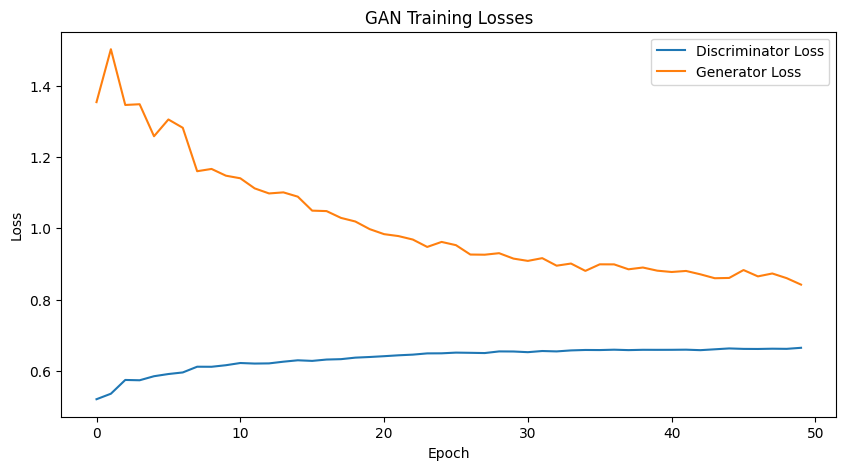

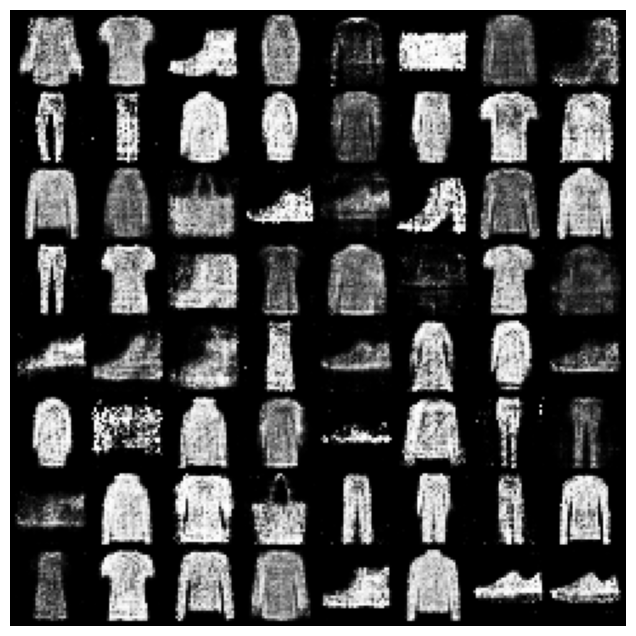

In [5]:
# ==============================
# GAN for Fashion-MNIST (Full Script)
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import os

# ------------------------------
# 1️⃣ Device & Output Folder
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
os.makedirs("gan_outputs", exist_ok=True)

# ------------------------------
# 2️⃣ Dataset
# ------------------------------
batch_size = 128
img_size = 28

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ------------------------------
# 3️⃣ Models
# ------------------------------
latent_dim = 100

class Generator(nn.Module):
    def __init__(self, latent_dim, img_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, img_size*img_size),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(out.size(0), 1, img_size, img_size)

class Discriminator(nn.Module):
    def __init__(self, img_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(img_size*img_size, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        x = img.view(img.size(0), -1)
        return self.model(x)

G = Generator(latent_dim, img_size).to(device)
D = Discriminator(img_size).to(device)

# ------------------------------
# 4️⃣ Optimizer & Loss
# ------------------------------
lr = 0.0002
num_epochs = 50

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

# ------------------------------
# 5️⃣ Training Loop
# ------------------------------
fixed_z = torch.randn(64, latent_dim).to(device)  # For consistent visualization
d_losses = []
g_losses = []

for epoch in range(1, num_epochs+1):
    d_loss_epoch = 0
    g_loss_epoch = 0

    for imgs, _ in train_loader:
        batch_size_curr = imgs.size(0)
        real_imgs = imgs.to(device)

        # Adversarial ground truths
        valid = torch.ones(batch_size_curr, 1).to(device)
        fake = torch.zeros(batch_size_curr, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(real_imgs), valid)
        fake_loss = criterion(D(fake_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        optimizer_G.zero_grad()
        z = torch.randn(batch_size_curr, latent_dim).to(device)
        gen_imgs = G(z)
        g_loss = criterion(D(gen_imgs), valid)
        g_loss.backward()
        optimizer_G.step()

        d_loss_epoch += d_loss.item()
        g_loss_epoch += g_loss.item()

    avg_d_loss = d_loss_epoch / len(train_loader)
    avg_g_loss = g_loss_epoch / len(train_loader)
    d_losses.append(avg_d_loss)
    g_losses.append(avg_g_loss)

    print(f"[Epoch {epoch}/{num_epochs}] D_loss: {avg_d_loss:.4f}, G_loss: {avg_g_loss:.4f}")

    # Save generated samples every 5 epochs
    if epoch % 5 == 0:
        with torch.no_grad():
            gen_imgs = G(fixed_z)
            save_image(make_grid(gen_imgs, nrow=8, normalize=True), f"gan_outputs/epoch_{epoch}.png")

# ------------------------------
# 6️⃣ Plot Losses
# ------------------------------
plt.figure(figsize=(10,5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN Training Losses")
plt.show()

# ------------------------------
# 7️⃣ Display final generated samples
# ------------------------------
with torch.no_grad():
    gen_imgs = G(fixed_z)
plt.figure(figsize=(8,8))
plt.axis('off')
plt.imshow(make_grid(gen_imgs, nrow=8, normalize=True).permute(1,2,0).cpu())
plt.show()